<a href="https://colab.research.google.com/github/Olga-Lyt/DTA-2026/blob/main/HW/17_06_practice_stat_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [18]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("shop_customers.csv")
ab = pd.read_csv("ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [4]:
# Завдання 1:
df.describe()



,customer_id,age,spend,session_min,sat_before,sat_after
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,34.646000,845.016340,20.739400,6.536000,7.138000
std,144.481833,10.961615,333.460589,10.532489,1.523597,1.826919
min,1001.000000,18.000000,50.000000,1.000000,2.000000,1.000000
25%,1125.750000,26.000000,612.627500,13.100000,6.000000,6.000000
50%,1250.500000,34.000000,834.750000,20.850000,7.000000,7.000000
75%,1375.250000,41.250000,1070.395000,27.400000,8.000000,9.000000
max,1500.000000,69.000000,1952.020000,52.200000,10.000000,10.000000


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [12]:
# Завдання 2:
df['channel'].value_counts()

,count
channel,
Органіка,174
Соцмережі,167
Реклама,159


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [6]:
# Завдання 3:
actual_mean_session_min = df['session_min'].mean()
print(f"Фактичний середній час на сайті: {actual_mean_session_min:.2f} хвилин")

t_stat, p_value = stats.ttest_1samp(df['session_min'], popmean=20)
print(f"t-статистика: {t_stat:.2f}")
print(f"p-значення: {p_value:.3f}")

Фактичний середній час на сайті: 20.74 хвилин
t-статистика: 1.57
p-значення: 0.117


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?



**Ваша відповідь:**

*Оскільки p-значення становить 0.117. що більше за 0.05, ми не маємо достатньо доказів, щоб відхилити нульову гіпотезу. Це означає, що немає статистично значущої різниці між фактичним середнім часом на сайті (20.74 хвилини) та заявленими 20 хвилинами. Отже, маркетолог мав рацію.*

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [7]:
# Завдання 4:
actual_mean_spend = df['spend'].mean()
print(f"Фактичні середні витрати: {actual_mean_spend:.2f} грн")

t_stat_spend, p_value_spend = stats.ttest_1samp(df['spend'], popmean=850)
print(f"t-статистика: {t_stat_spend:.2f}")
print(f"p-значення: {p_value_spend:.3f}")

Фактичні середні витрати: 845.02 грн
t-статистика: -0.33
p-значення: 0.738


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**  

Тест показав, що p-значення становить 0.738. Оскільки це значення значно вище за 0.05, ми не маємо достатніх доказів, щоб відхилити нульову гіпотезу. Це означає, що немає статистично значущої різниці між фактичними середніми витратами клієнтів (845.02 грн) та заявленими 850 грн. Те, що ми не відхиляємо нульову гіпотезу не означає, що середнє точно дорівнює 850 грн, а лише те, що наявних даних недостатньо, щоб стверджувати зворотне з певним рівнем статистичної значущості.

*...*

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [8]:
# Завдання 5:
spend_mobile = df[df['device'] == 'Mobile']['spend']
spend_desktop = df[df['device'] == 'Desktop']['spend']

print(f"Середні витрати для Mobile: {spend_mobile.mean():.2f} грн")
print(f"Середні витрати для Desktop: {spend_desktop.mean():.2f} грн")

t_stat_device, p_value_device = stats.ttest_ind(spend_mobile, spend_desktop)
print(f"t-статистика: {t_stat_device:.2f}")
print(f"p-значення: {p_value_device:.3f}")

Середні витрати для Mobile: 835.21 грн
Середні витрати для Desktop: 861.16 грн
t-статистика: -0.84
p-значення: 0.399


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Оскільки p-значення становить 0.399, що вище за 0.05, ми не маємо достатніх статистичних доказів, щоб відхилити нульову гіпотезу. Це означає, що немає статистично значущої різниці у витратах між користувачами мобільних пристроїв та десктопів.

На місці аналітика я б не порадила компанії інвестувати значні кошти в мобільну версію, базуючись лише на цих даних про витрати, оскільки спостережувана різниця (835.21 грн для Mobile проти 861.16 грн для Desktop) може бути випадковою і не є статистично значущою.

**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [9]:
# Завдання 6:
session_min_male = df[df['gender'] == 'Ч']['session_min']
session_min_female = df[df['gender'] == 'Ж']['session_min']

print(f"Середній час на сайті для чоловіків: {session_min_male.mean():.2f} хвилин")
print(f"Середній час на сайті для жінок: {session_min_female.mean():.2f} хвилин")

t_stat_gender, p_value_gender = stats.ttest_ind(session_min_male, session_min_female)
print(f"t-статистика: {t_stat_gender:.2f}")
print(f"p-значення: {p_value_gender:.3f}")

Середній час на сайті для чоловіків: 20.85 хвилин
Середній час на сайті для жінок: 20.63 хвилин
t-статистика: 0.23
p-значення: 0.816


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Оскільки p-значення становить 0.816, що значно більше за 0.05, ми не маємо достатньо статистичних доказів, щоб відхилити нульову гіпотезу. Це означає, що немає статистично значущої різниці у середньому часі, проведеному на сайті, між чоловіками та жінками.

На практиці для команди маркетингу це означає, що немає потреби розробляти окремі стратегії для залучення чи утримання чоловіків та жінок на сайті, ґрунтуючись лише на тривалості їхніх сесій.

---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [10]:
# Завдання 7:
mean_sat_before = df['sat_before'].mean()
mean_sat_after = df['sat_after'].mean()

print(f"Середня задоволеність до редизайну: {mean_sat_before:.2f}")
print(f"Середня задоволеність після редизайну: {mean_sat_after:.2f}")

t_stat_paired, p_value_paired = stats.ttest_rel(df['sat_before'], df['sat_after'])
print(f"t-статистика: {t_stat_paired:.2f}")
print(f"p-значення: {p_value_paired:.3f}")

Середня задоволеність до редизайну: 6.54
Середня задоволеність після редизайну: 7.14
t-статистика: -11.30
p-значення: 0.000


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

На мою думку, редизайн спрацював, оскільки середня задоволеність після редизайну (7,14) більша, ніж до нього (6,54).  
Тут є доречним саме парний тест, оскільки ми порівнювали два виміри (sat_before та sat_after) у одних і тих самих клієнтів. Тобто, дані до і після редизайну є залежними. Парний тест враховує цю залежність, порівнюючи середнє арифметичне різниць між парами вимірів, що дозволяє більш точно виявити ефект зміни.

Якби ми використали звичайний двовибірковий t-тест (ttest_ind), це було б неправильно, оскільки він припускає, що групи незалежні (тобто, що sat_before і sat_after належать різним людям). Такий підхід ігнорував би внутрішньогрупову варіацію та міг би  призвести до нездатності виявити реальну зміну, навіть якщо вона була присутня.  

---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [11]:
# Завдання 8:
spend_organika = df[df['channel'] == 'Органіка']['spend']
spend_reklama = df[df['channel'] == 'Реклама']['spend']
spend_socmerezhi = df[df['channel'] == 'Соцмережі']['spend']

print(f"Середні витрати для каналу 'Органіка': {spend_organika.mean():.2f} грн")
print(f"Середні витрати для каналу 'Реклама': {spend_reklama.mean():.2f} грн")
print(f"Середні витрати для каналу 'Соцмережі': {spend_socmerezhi.mean():.2f} грн")

f_stat_channel, p_value_channel = stats.f_oneway(spend_organika, spend_reklama, spend_socmerezhi)
print(f"F-статистика: {f_stat_channel:.2f}")
print(f"p-значення: {p_value_channel:.3f}")

Середні витрати для каналу 'Органіка': 791.28 грн
Середні витрати для каналу 'Реклама': 1057.87 грн
Середні витрати для каналу 'Соцмережі': 698.35 грн
F-статистика: 63.54
p-значення: 0.000


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Якщо подивитись на середні значення, канал 'Реклама' виглядає найприбутковішим із середніми витратами 1057.87 грн, тоді як 'Органіка' має 791.28 грн, а 'Соцмережі' — 698.35 грн.

Проте, на основі лише ANOVA, ми не можемо точно сказати, що, наприклад, 'Реклама' значущо краща за 'Органіку', або що 'Соцмережі' значущо гірші за 'Органіку'. ANOVA лише повідомляє нам, що принаймні одна пара груп має статистично значущу відмінність, але не вказує, які саме. Щоб визначити конкретні відмінності між парами каналів, потрібно провести додаткові попарні порівняння.

**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [14]:
# Завдання 9:
unique_countries = df['country'].unique()
session_min_groups = []
mean_session_mins = {}

print("Середній час на сайті за країною:")
for country in unique_countries:
    country_data = df[df['country'] == country]['session_min']
    if not country_data.empty:
        session_min_groups.append(country_data)
        mean_session_mins[country] = country_data.mean()
        print(f"  {country}: {country_data.mean():.2f} хвилин")
    else:
        print(f"  Країна '{country}' відсутня в даних або не має записів session_min, тому буде пропущена.")


if len(session_min_groups) >= 2:
    f_stat_country, p_value_country = stats.f_oneway(*session_min_groups)
    print(f"\nF-статистика: {f_stat_country:.2f}")
    print(f"p-значення: {p_value_country:.3f}")
else:
    print("\nНедостатньо груп (потрібно мінімум 2) для виконання ANOVA. F-статистика та p-значення не можуть бути розраховані.")
    f_stat_country, p_value_country = float('nan'), float('nan')


Середній час на сайті за країною:
  Німеччина: 21.29 хвилин
  Україна: 20.29 хвилин
  Польща: 21.17 хвилин

F-статистика: 0.49
p-значення: 0.611


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**  

Оскільки p-значення (0.611) більше за 0.05, ми не маємо достатньо статистичних доказів, щоб відхилити нульову гіпотезу. Це означає, що немає статистично значущої різниці в середньому часі, проведеному на сайті, між клієнтами з Німеччини, України та Польщі. Тобто, будь-які відмінності в середньому часі, проведеному на сайті, між цими країнами, швидше за все, є випадковими.

---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [15]:
# Завдання 10:
contingency_table = pd.crosstab(df['channel'], df['purchased'])
display(contingency_table)

chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nХі-квадрат статистика: {chi2_stat:.2f}")
print(f"p-значення: {p_value_chi2:.3f}")

purchased,Ні,Так
channel,,
Органіка,116,58
Реклама,110,49
Соцмережі,107,60



Хі-квадрат статистика: 0.96
p-значення: 0.620


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Тест хі-квадрат не виявив  значущого зв'язку між каналом залучення та  покупкою, оскільки p-значення (0.620) значно перевищує рівень значущості 0.05. Це означає, що розподіл покупців і непокупців є приблизно однаковим у всіх каналах залучення.

Для бізнесу це означає, що  на основі цих даних немає підстав обирати певний канал залучення, орієнтуючись лише на підвищення ймовірності покупки.

**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [16]:
# Завдання 11:
contingency_gender_device = pd.crosstab(df['gender'], df['device'])
display(contingency_gender_device)

chi2_stat_gender_device, p_value_gender_device, dof_gender_device, expected_gender_device = stats.chi2_contingency(contingency_gender_device)

print(f"\nХі-квадрат статистика: {chi2_stat_gender_device:.2f}")
print(f"p-значення: {p_value_gender_device:.3f}")

device,Desktop,Mobile
gender,,
Ж,93,158
Ч,96,153



Хі-квадрат статистика: 0.06
p-значення: 0.799


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Оскільки p-значення (0.799) значно перевищує 0.05, ми не маємо достатніх  доказів, щоб відхилити нульову гіпотезу. Це означає, що немає статистично значущого зв'язку між статтю клієнта та типом пристрою, який він використовує. За цими даними не можна сказати, що чоловіки й жінки користуються різними пристроями. Розподіл використання пристроїв є схожим для обох статей.

---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

Коефіцієнт кореляції Пірсона (r): 0.73
p-значення: 0.000


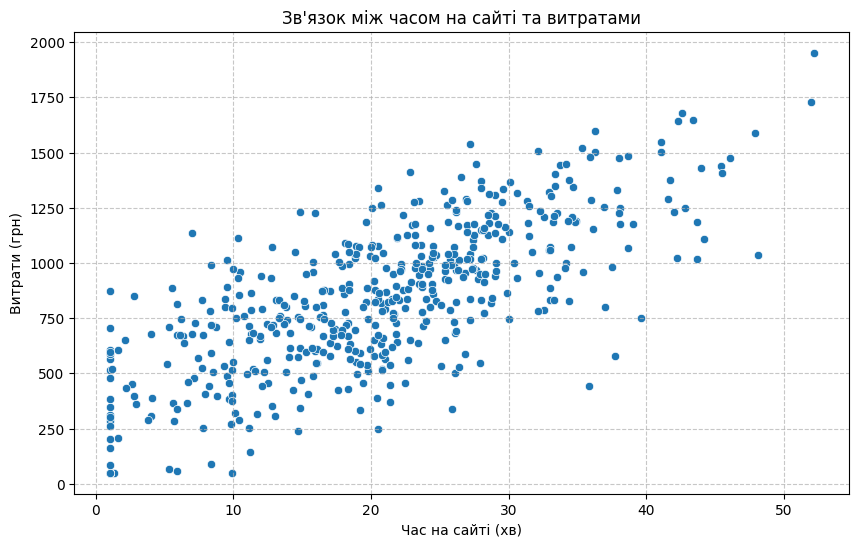

In [19]:
# Завдання 12:
r, p_value_corr = stats.pearsonr(df['session_min'], df['spend'])

print(f"Коефіцієнт кореляції Пірсона (r): {r:.2f}")
print(f"p-значення: {p_value_corr:.3f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='session_min', y='spend', data=df)
plt.title('Зв\'язок між часом на сайті та витратами')
plt.xlabel('Час на сайті (хв)')
plt.ylabel('Витрати (грн)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Коефіцієнт кореляції Пірсона (r) становить 0.73, а p-значення — 0.000. Це вказує на сильний прямий та статистично значущий зв'язок між часом, проведеним на сайті, та витратами. Тобто, зі збільшенням часу, який клієнт проводить на сайті, його витрати, як правило, також збільшуються.

Однак, кореляція ще не означає причинно-наслідковий зв'язок. Навіть попри те, що ми бачимо сильний зв'язок, ми не можемо стверджувати, що довший час на сайті спричиняє більші витрати. Можливо, обидва ці показники залежать від якогось третього фактора.

**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

In [20]:
# Завдання 13:
r_age_spend, p_value_age_spend = stats.pearsonr(df['age'], df['spend'])

print(f"Коефіцієнт кореляції Пірсона (r) між віком та витратами: {r_age_spend:.2f}")
print(f"p-значення: {p_value_age_spend:.3f}")

Коефіцієнт кореляції Пірсона (r) між віком та витратами: -0.04
p-значення: 0.351


#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Кореляція між віком та витратами показала коефіцієнт Пірсона -0.04 та p-значення 0.351. Це свідчить про дуже слабкий, зворотний зв'язок, який є статистично незначущим, оскільки p-значення (0.351) значно перевищує 0.05. Тобто, на основі цих даних не можна стверджувати, що існує лінійний зв'язок між віком клієнта та його витратами.

Порівнюючи цей результат із попереднім, де кореляція між часом на сайті та витратами становила  0.73 та p = 0.000, ми бачимо, що зв'язок між часом на сайті та витратами є значно сильнішим, прямим та статистично значущим, ніж зв'язок між віком та витратами. Для бізнесу це важливо, оскільки вказує на те, що час, проведений клієнтом на сайті, є набагато кращим індикатором його потенційних витрат, ніж вік.

---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [21]:
# Завдання 14:
ab['group'].value_counts()

,count
group,
A,4000
B,4000


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [22]:
# Завдання 15:
conversion_rates = ab.groupby('group')['converted'].mean()
display(conversion_rates)

diff_conversion = (conversion_rates['B'] - conversion_rates['A']) * 100
print(f"Різниця в конверсії між групою B та групою A: {diff_conversion:.2f} відсоткових пунктів")

,converted
group,
A,0.101
B,0.119


Різниця в конверсії між групою B та групою A: 1.80 відсоткових пунктів


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Група B показує вищу конверсію (0.119 або 11.9%) порівняно з групою A (0.101 або 10.1%), з різницею в 1.80 відсоткових пунктів. Однак, ця різниця в числах ще не означає, що версія B точно краща і її варто впроваджувати.

Ми не можемо зробити остаточний висновок лише на основі цих чисел, без статистичного тесту, тому що спостережувана різниця може бути результатом випадковості або шуму у даних. Статистичний тест дозволить нам визначити ймовірність того, що така  різниця могла виникнути випадково.

**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Нульова гіпотеза (H₀): Між конверсією групи A (стара версія) та групи B (нова версія) немає статистично значущої різниці. Будь-яка спостережувана різниця є випадковою.

Альтернативна гіпотеза (H₁): Між конверсією групи A та групи B існує статистично значуща різниця. Нова версія (група B) впливає на конверсію.

**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [23]:
# Завдання 16:
contingency_ab = pd.crosstab(ab['group'], ab['converted'])
display(contingency_ab)

chi2_stat_ab, p_value_ab, dof_ab, expected_ab = stats.chi2_contingency(contingency_ab)

print(f"\nХі-квадрат статистика: {chi2_stat_ab:.2f}")
print(f"p-значення: {p_value_ab:.3f}")

converted,0,1
group,,
A,3596,404
B,3524,476



Хі-квадрат статистика: 6.44
p-значення: 0.011


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

На основі p-значення (0.011), яке є меншим за рівень значущості α = 0.05, ми можемо відхилити нульову гіпотезу. Це означає, що різниця в конверсії між версією А та версією В є статистично значущою.

Враховуючи, що версія В показала вищу конверсію, і ця різниця є статистично значущою, моя рекомендація для продуктової команди полягає в тому, щоб впроваджувати версію В. Спостережуване покращення, швидше за все, не є випадковим і свідчить про те, що нова версія сайту ефективніша.

---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [ ]:
# Завдання 17:


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [ ]:
# Завдання 18:


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [ ]:
# Завдання 19:


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

In [ ]:
# Завдання 20:


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
